In [2]:
!pip install kagglehub

In [3]:
import kagglehub
cloudoak_lpd_5_cleansed_path = kagglehub.dataset_download('cloudoak/lpd-5-cleansed')
print(cloudoak_lpd_5_cleansed_path)
print('Data source import complete.')

/root/.cache/kagglehub/datasets/cloudoak/lpd-5-cleansed/versions/1
Data source import complete.


In [4]:
# Imports
!apt-get install -y timidity
!pip install midi2audio
!pip install -q pretty_midi
!pip install -q pypianoroll

import pretty_midi
from midi2audio import FluidSynth
from IPython.display import Audio

import pypianoroll
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

import os
from tqdm.notebook import tqdm
from PIL import Image

from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import torch.nn as nn
import torch
import torch.optim as optim
import torch.autograd as autograd

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
timidity is already the newest version (2.14.0-8.2ubuntu1).
The following packages were automatically installed and are no longer required:
  cmake-data librhash0 libuv1t64
Use 'apt autoremove' to remove them.
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.


/opt/conda/envs/py_3.12/lib/python3.12/site-packages/redis/connection.py:77: UserWarning: redis-py works best with hiredis. Please consider installing
  warnings.warn(msg)


In [5]:
# Define Sizes

batch_size = 32
num_workers = 20
inp_dim = 128

path = "/root/.cache/kagglehub/datasets/cloudoak/lpd-5-cleansed/versions/1/lpd_5_cleansed/lpd_5/lpd_5_cleansed/B/Z/B/TRBZBJP12903CB24FB/91901a77e4390431b2b1f245f30f8984.npz"
multitrack = pypianoroll.load(path)
track_names = ["Drums", "Bass", "Guitar", "Strings", "Piano"]

In [6]:
class PRDataset(Dataset):
    def __init__(self, root_dir, tracks=5, bar_len=96, bars_per_sample=4, pitch_size=128, transform=None):

        self.root_dir = root_dir
        self.transform = transform
        self.bar_len = bar_len
        self.bars_per_sample = bars_per_sample
        self.pitch_size = pitch_size
        self.tracks = tracks
        self.samples = []

        for root, _, files in tqdm(os.walk(self.root_dir)):
            for file in files:
                if file.lower().endswith('.npz'):
                    multitrack = pypianoroll.load(os.path.join(root, file))
                    num_time_steps = multitrack.tracks[0].pianoroll.shape[0]
                    num_bars = num_time_steps // bar_len
                    self.samples.append((os.path.join(root, file), num_bars))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, num_bars = self.samples[idx]
        multitrack = pypianoroll.load(path)

        # Sample random starting bar index
        start_bar = np.random.randint(0, max(1, num_bars - self.bars_per_sample + 1))
        start = start_bar * self.bar_len
        end = start + self.bar_len * self.bars_per_sample

        rolls = []
        for track in multitrack.tracks:
            pr = track.pianoroll[start:end]

            # Pad time axis if needed
            if pr.shape[0] < self.bar_len * self.bars_per_sample:
                pad_width = ((0, self.bar_len * self.bars_per_sample - pr.shape[0]), (0, 0))
                pr = np.pad(pr, pad_width, mode="constant")

            # Pad/crop pitch axis
            if pr.shape[1] < self.pitch_size:
                pad_width = ((0, 0), (0, self.pitch_size - pr.shape[1]))
                pr = np.pad(pr, pad_width, mode="constant")
            elif pr.shape[1] > self.pitch_size:
                pr = pr[:, :self.pitch_size]

            rolls.append(pr)

        # Pad tracks if needed
        while len(rolls) < self.tracks:
            rolls.append(np.zeros((self.bar_len * self.bars_per_sample, self.pitch_size)))

        rolls = np.stack(rolls, axis=0)
        rolls = torch.tensor(rolls, dtype=torch.float32) / 127.0

        if self.transform:
            return self.transform(rolls)
        return rolls

In [7]:
transform = transforms.Compose([
    transforms.Normalize((0.5,)*5, (0.5,)*5)     
])

root_dir = "/root/.cache/kagglehub/datasets/cloudoak/lpd-5-cleansed/versions/1/lpd_5_cleansed/lpd_5/lpd_5_cleansed/"

dataset = PRDataset(root_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=True)

0it [00:00, ?it/s]

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [9]:
# For the critic
def wasserstein_critic_loss(real_output, fake_output):
    return torch.mean(fake_output) - torch.mean(real_output)

# For the generator
def wasserstein_generator_loss(fake_output):
    return -torch.mean(fake_output)

# Gradient Penalty

def gradient_penalty(critic, real_data, fake_data, device=device, lambda_gp=10):
    batch_size = real_data.size(0)
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    alpha = alpha.expand_as(real_data)

    if real_data.shape != fake_data.shape:
        fake_data = F.interpolate(fake_data, size=real_data.shape[2:], mode='bilinear', align_corners=False)
    
    interpolate = alpha * real_data + (1 - alpha) * fake_data
    interpolate = interpolate.to(device).requires_grad_(True)

    interpolated_score = critic(interpolate)

    gradients = autograd.grad(
        outputs=interpolated_score,
        inputs=interpolate,
        grad_outputs=torch.ones_like(interpolated_score),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.view(batch_size, -1)
    gradient_norm = gradients.norm(2, dim=1)

    gradient_penalty = lambda_gp * ((gradient_norm - 1) ** 2).mean()
    return gradient_penalty

In [10]:
class TrackGenerator(nn.Module):
    def __init__(self, input_dim, out_dim, hidden_dim, pitch_range, time_res):
        super().__init__()

        self.pitch_range = pitch_range
        self.time_res = time_res

        self.project = nn.Sequential(
            
            nn.Linear(input_dim, 256 * 6 * 8),
            nn.ReLU()
        )
        
        self.deconv = nn.Sequential(
            
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # (128, 12, 16)
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # (64, 24, 32)
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),     # (1, 48, 64)
            nn.ReLU()
        )

    def forward(self, x):
        batch_size = x.size(0)
        x = self.project(x)                   # (batch, 256*6*8)
        x = x.view(batch_size, 256, 6, 8)     # (batch, 256, 6, 8)
        x = self.deconv(x)                    # (batch, 1, pitch_range, time_res)
        x = F.interpolate(x, size=(self.pitch_range, self.time_res), mode='bilinear', align_corners=False)
        x = torch.clamp(x, 0, 127) 
        return x.squeeze(1)                   # (batch, pitch_range, time_res)

In [11]:
class BarGenerator(nn.Module) :
    def __init__(self, input_dim, out_dim, hidden_dim, pitch_range, time_res):
        super().__init__()

        self.pitch_range = pitch_range
        self.time_res = time_res

        self.model = nn.Sequential(
            
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, out_dim),
            nn.ReLU()
        )
        
    def forward(self, x):
        return self.model(x)   # [B, out_dim]

In [12]:
class HybridMuseGenerator(nn.Module):
    def __init__(self, latent_dim=128, z_t_dim=32, z_i_dim=32, z_it_dim=32, time_steps=4, num_tracks=5, pitch_range=128, time_res=96, hidden_dim=256):
        super().__init__()

        self.latent_dim = latent_dim
        self.z_t_dim = z_t_dim
        self.z_i_dim = z_i_dim
        self.z_it_dim = z_it_dim
        self.time_steps = time_steps
        self.num_tracks = num_tracks
        self.pitch_range = pitch_range
        self.time_res = time_res

        self.out_dim = pitch_range * time_res

        self.bar_generator = BarGenerator(
                input_dim = z_t_dim,
                out_dim = hidden_dim,
                hidden_dim = hidden_dim,
                pitch_range = self.pitch_range,
                time_res = self.time_res
            )

        self.track_generators = nn.ModuleList([
            TrackGenerator(
                input_dim = z_i_dim + z_it_dim + 2 * hidden_dim,
                out_dim = self.out_dim,
                hidden_dim = hidden_dim,
                pitch_range = self.pitch_range,
                time_res = self.time_res
            ) for _ in range(num_tracks)
        ])

    def forward(self, z, z_t, z_i_list, z_it_list):
        batch_size = z_t.size(0)
        
        temporal_context_track = []
        for track_idx in range(self.num_tracks):
            for t in range(self.time_steps):
                z_step = z[:, track_idx, t, :]
                context_t_track = self.bar_generator(z_step)  # [B, hidden_dim]
                temporal_context_track.append(context_t_track)
        
        temporal_context = []
        for t in range(self.time_steps):
            z_t_step = z_t[:, t, :]  # [B, z_t_dim]
            context_t = self.bar_generator(z_t_step)  # [B, hidden_dim]
            temporal_context.append(context_t)

        outputs = []
        
        for track_idx in range(self.num_tracks):
            z_i = z_i_list[track_idx]
            track_outputs = []
            
            for t in range(self.time_steps):
                z_it = z_it_list[track_idx][t]
                
                combine_ip = torch.cat([z_i, z_it, temporal_context[t], temporal_context_track[track_idx]], dim=1)
                
                pianoroll = self.track_generators[track_idx](combine_ip)

                track_outputs.append(pianoroll)
            track_outputs = torch.stack(track_outputs, dim=1)
            outputs.append(track_outputs)

        outputs = torch.stack(outputs, dim=1)
        batch_size, num_tracks, time_steps, pitch_range, time_res = outputs.shape
        
        # output shape: [B, N, T, P, R]
        # outputs = outputs.permute(0, 1, 3, 2, 4)  # [B, N, P, T, R]
        outputs = outputs.reshape(batch_size, self.num_tracks, self.pitch_range, self.time_steps * self.time_res)

        return outputs

In [13]:
# Discriminator

class Discriminator(nn.Module):
    def __init__(self, inc=5):
        super(Discriminator, self).__init__()
        
        self.model = nn.Sequential(
            nn.Conv2d(inc, 64, kernel_size=4, stride=2, padding=1), 
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True), 
            
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        out = self.model(x)      
        return out.view(out.size(0), -1).mean(dim=1, keepdim=True)

In [14]:
# Initialize models

generator = HybridMuseGenerator().to(device)
discriminator = Discriminator().to(device)

opt_G = torch.optim.Adam(generator.parameters(), lr=0.0001, betas=(0.5, 0.9))
opt_D = torch.optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.9))

  0%|          | 0/334 [00:00<?, ?it/s]

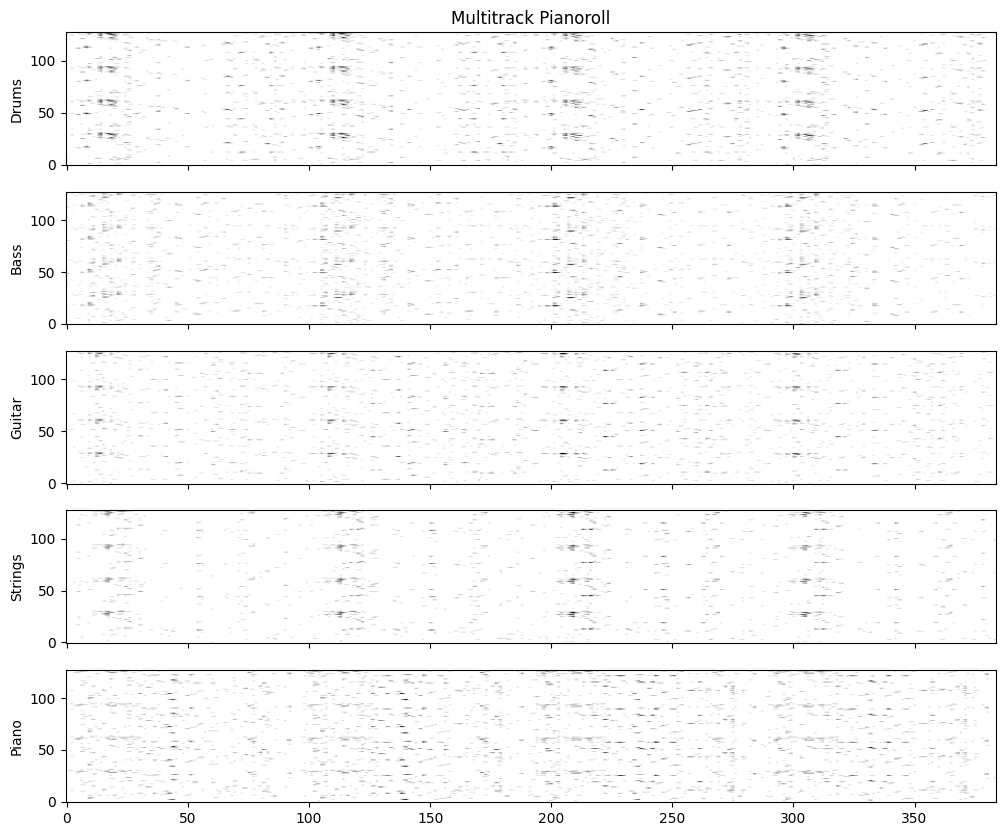

Saved sample: ./sample_epoch0.npz


  0%|          | 0/334 [00:00<?, ?it/s]

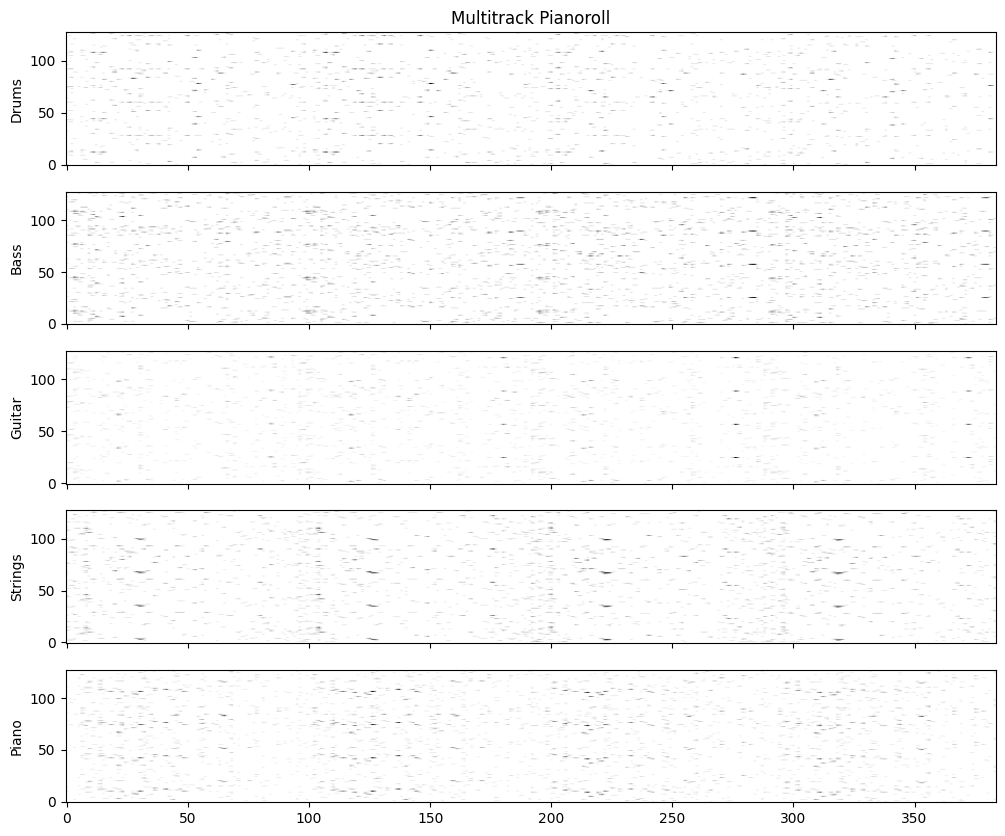

Saved sample: ./sample_epoch1.npz


  0%|          | 0/334 [00:00<?, ?it/s]

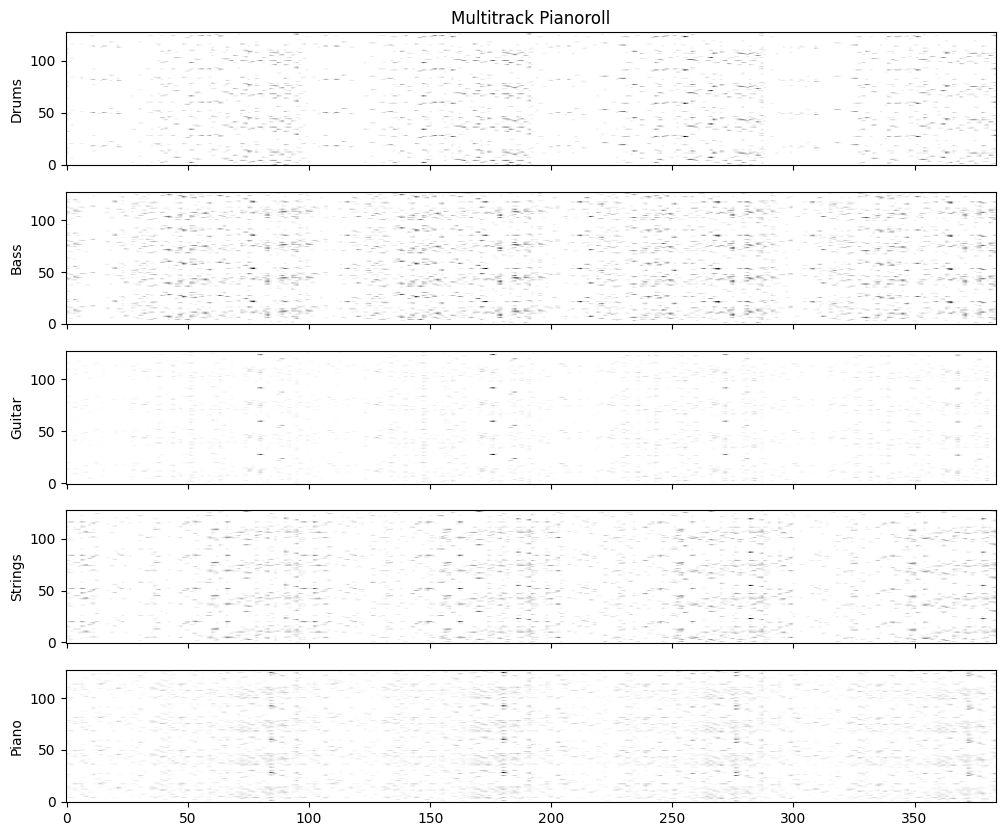

Saved sample: ./sample_epoch2.npz


  0%|          | 0/334 [00:00<?, ?it/s]

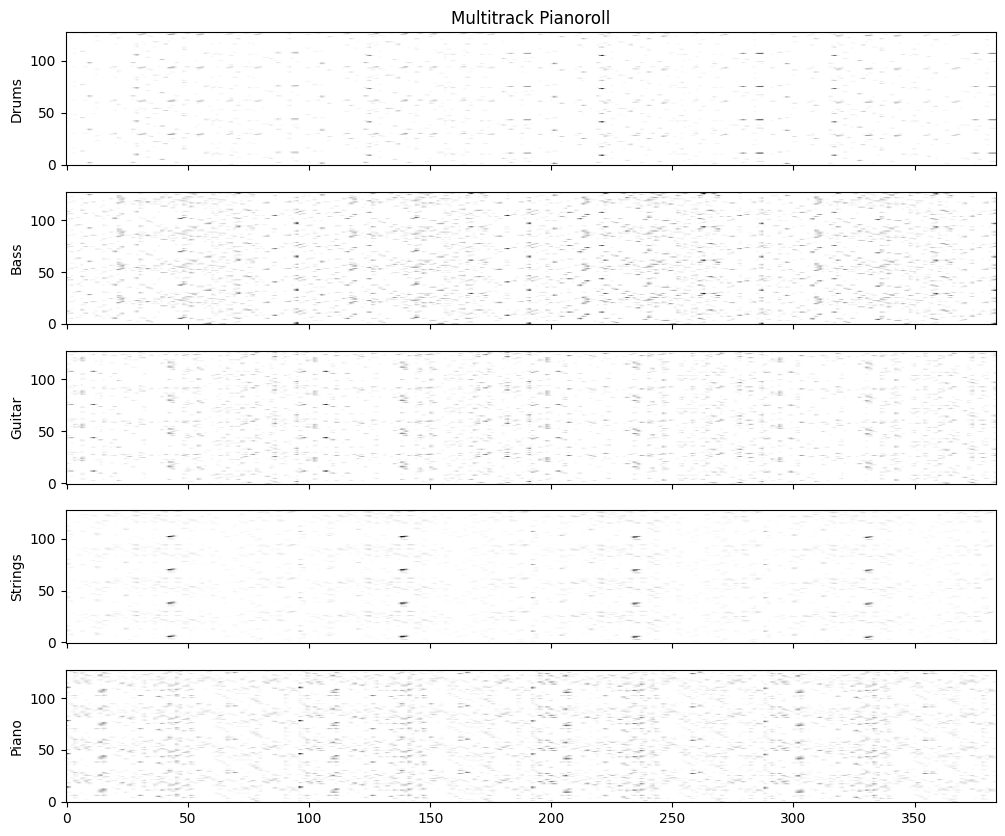

Saved sample: ./sample_epoch3.npz


  0%|          | 0/334 [00:00<?, ?it/s]

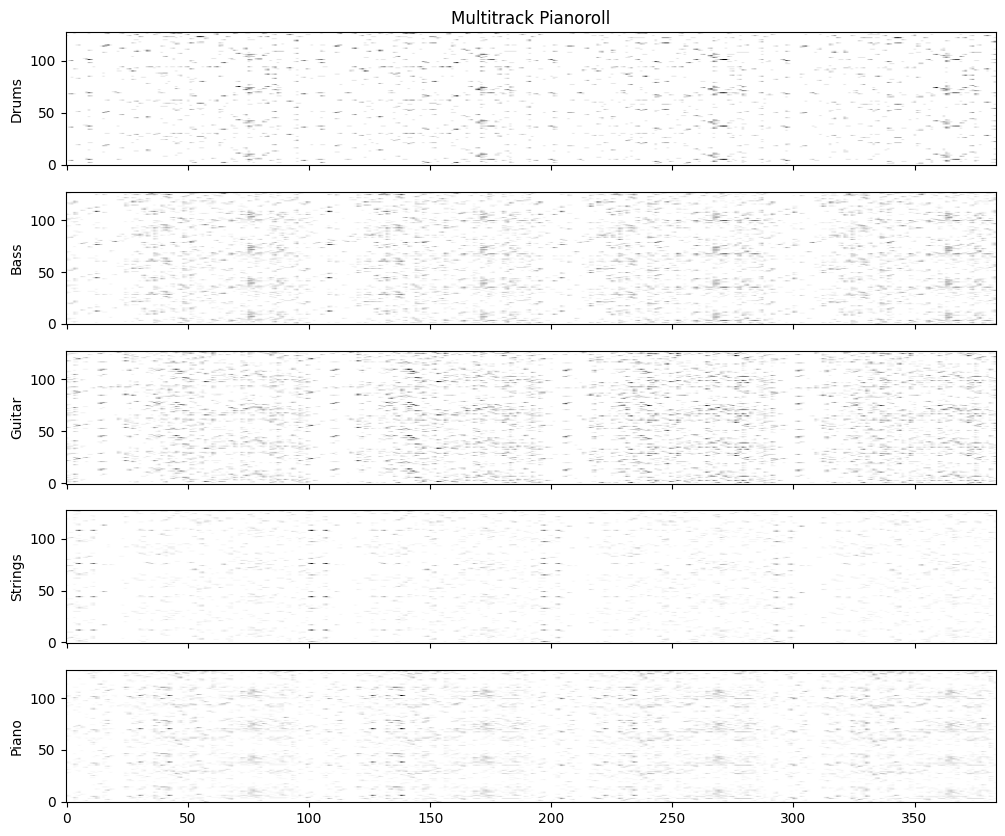

Saved sample: ./sample_epoch4.npz


  0%|          | 0/334 [00:00<?, ?it/s]

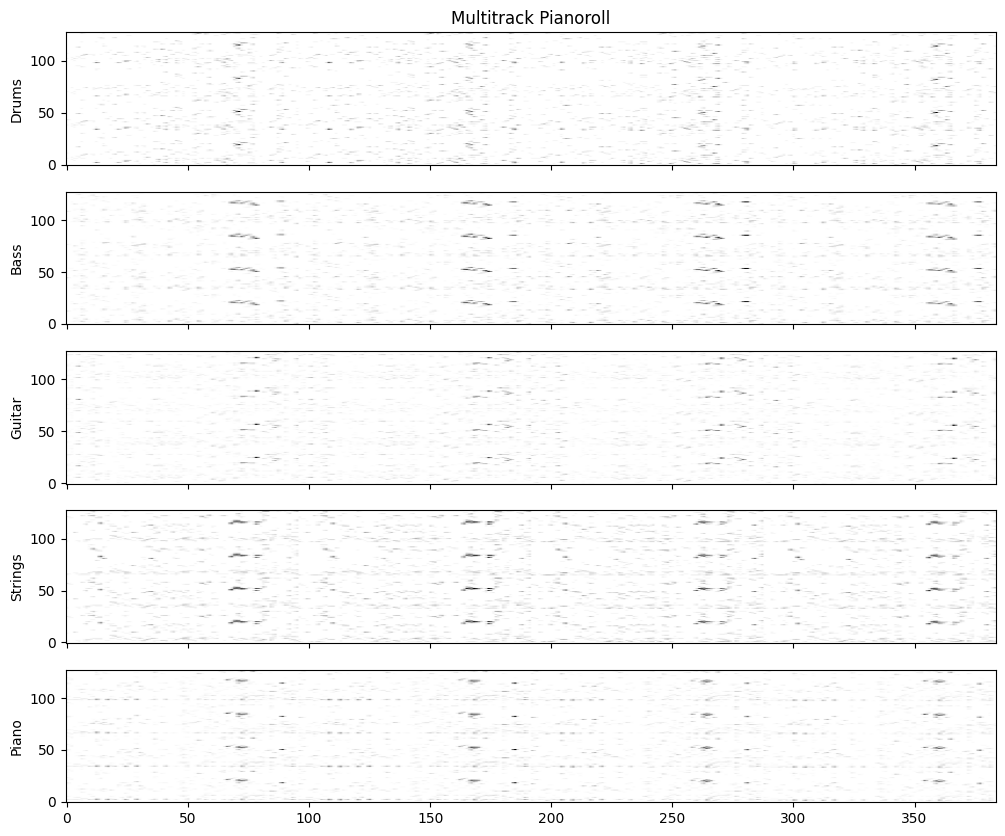

Saved sample: ./sample_epoch5.npz


  0%|          | 0/334 [00:00<?, ?it/s]

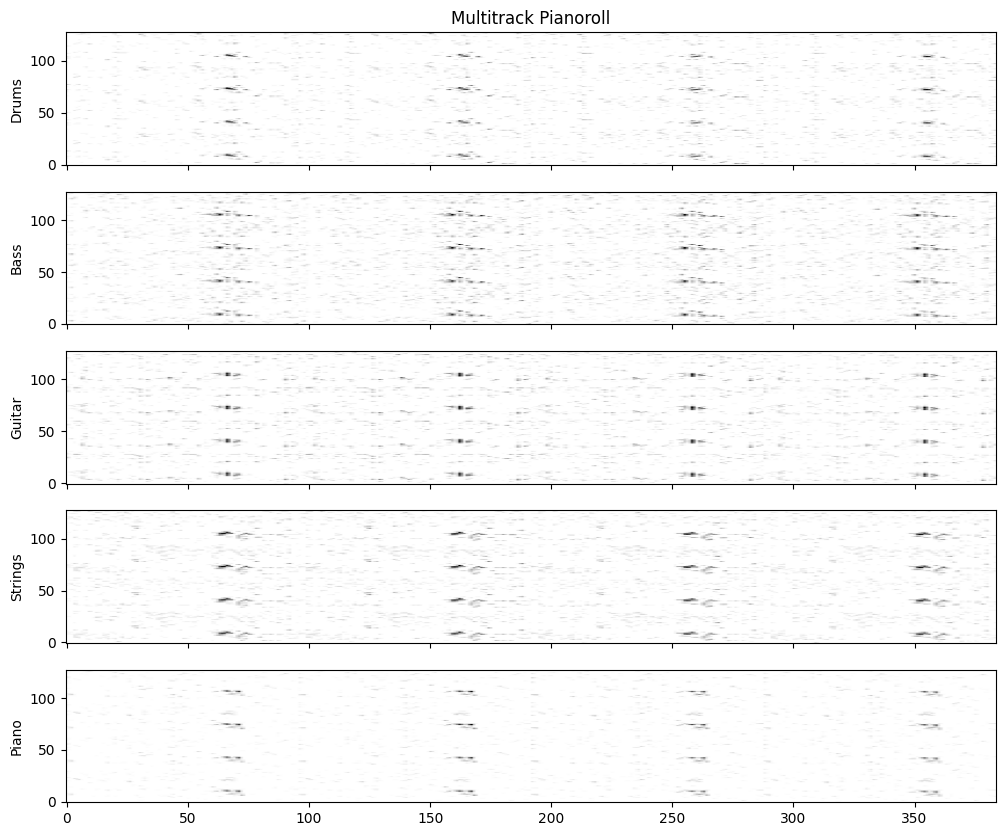

Saved sample: ./sample_epoch6.npz


  0%|          | 0/334 [00:00<?, ?it/s]

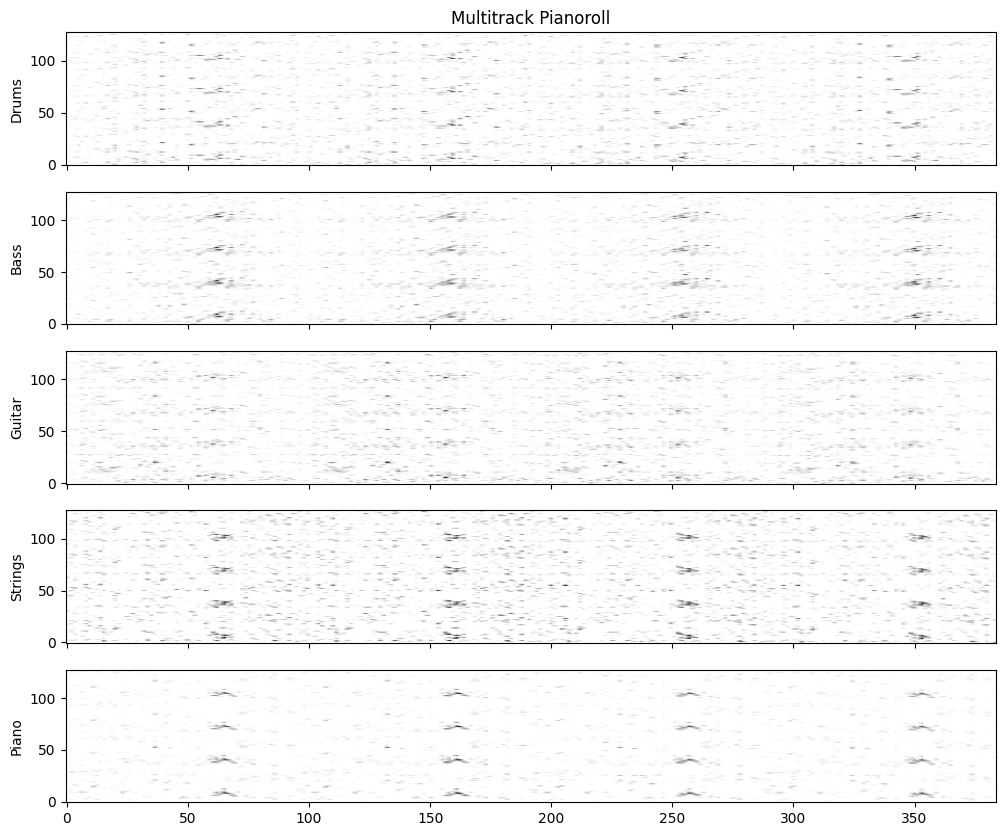

Saved sample: ./sample_epoch7.npz


  0%|          | 0/334 [00:00<?, ?it/s]

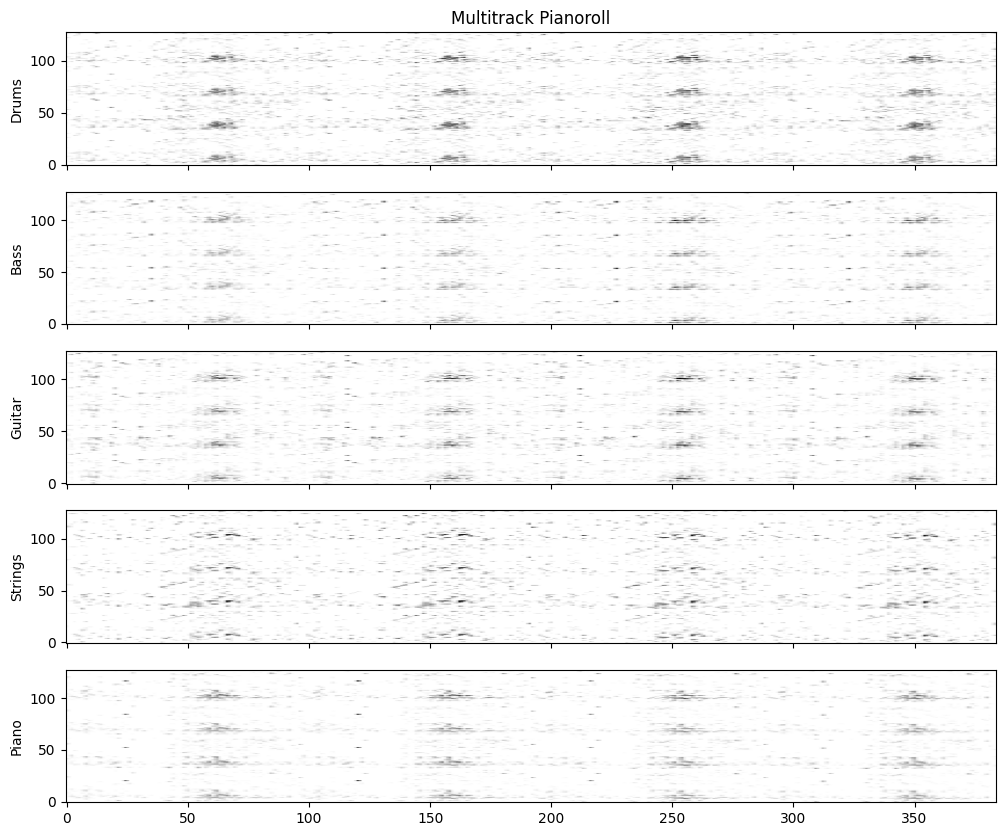

Saved sample: ./sample_epoch8.npz


  0%|          | 0/334 [00:00<?, ?it/s]

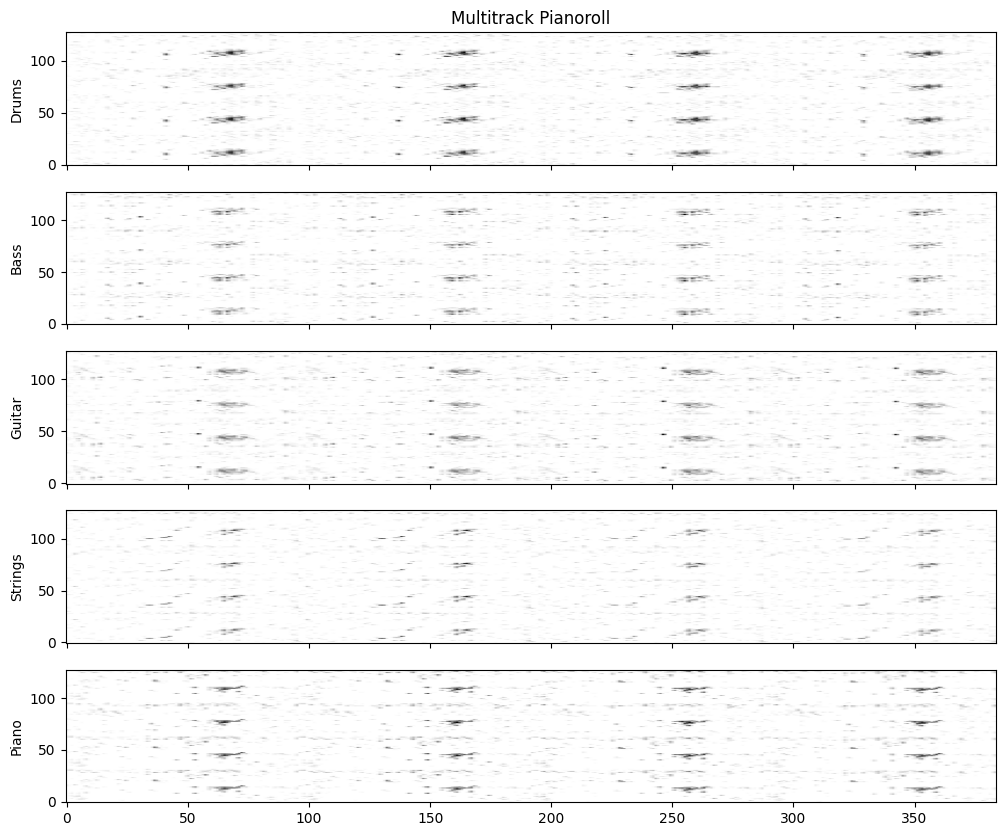

Saved sample: ./sample_epoch9.npz


  0%|          | 0/334 [00:00<?, ?it/s]

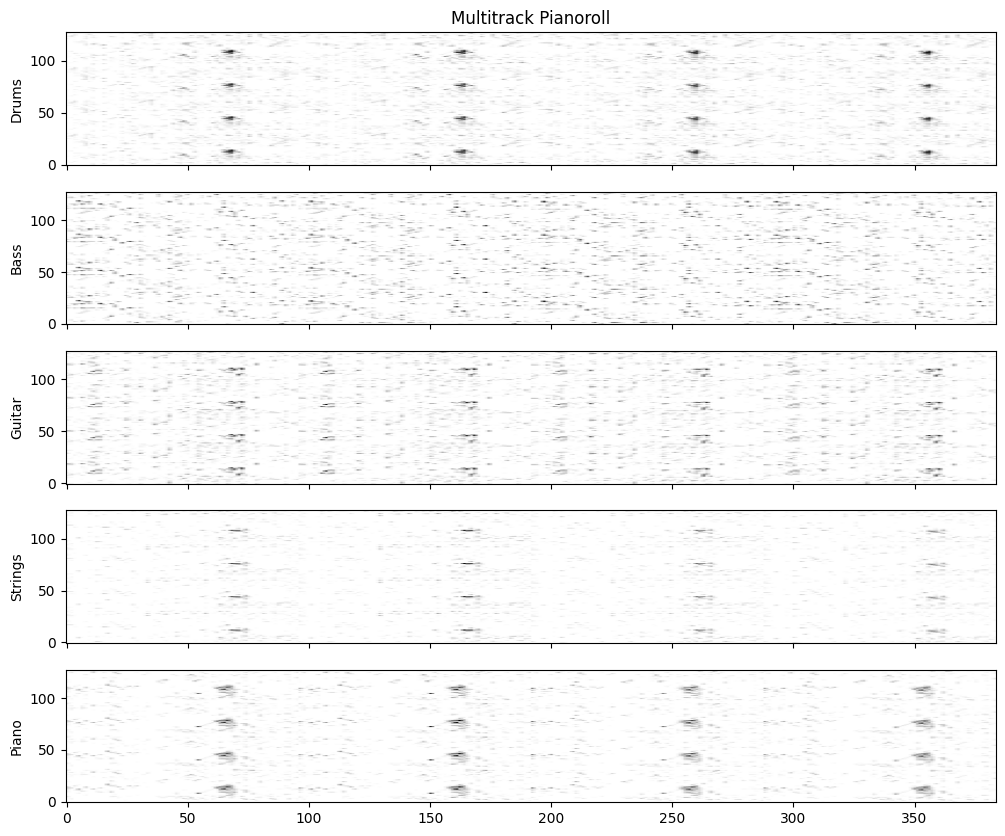

Saved sample: ./sample_epoch10.npz


  0%|          | 0/334 [00:00<?, ?it/s]

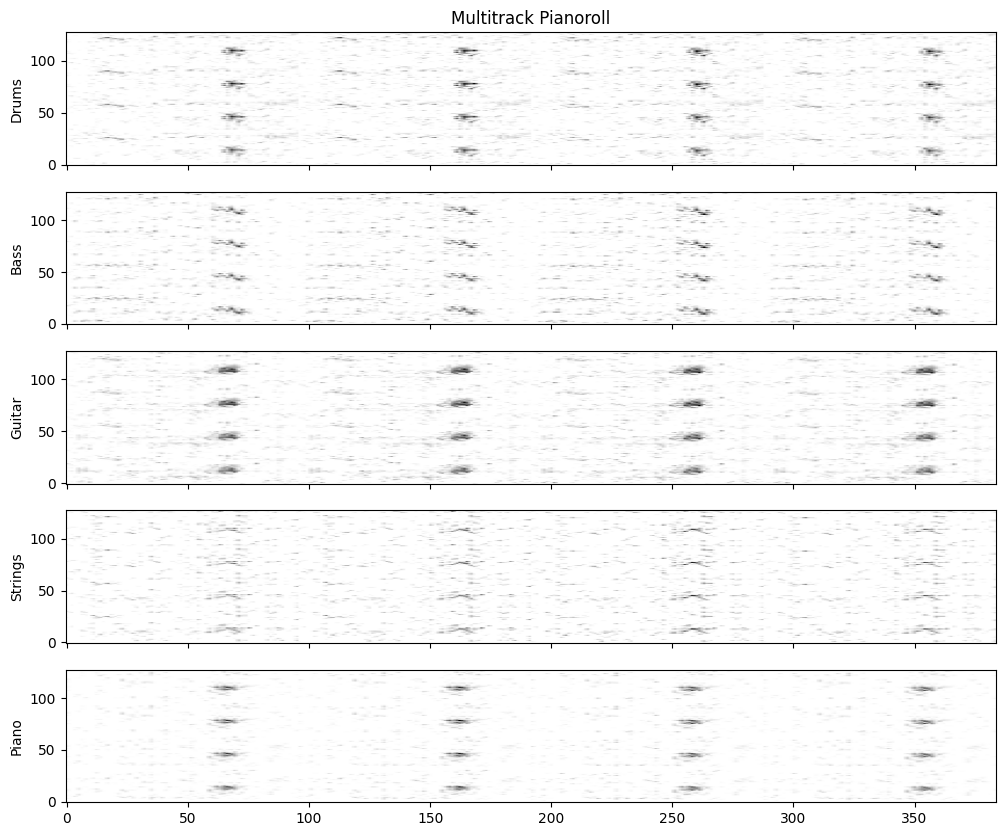

Saved sample: ./sample_epoch11.npz


  0%|          | 0/334 [00:00<?, ?it/s]

In [ ]:
# Training Loop
num_epochs = 30

z_t_dim = 32
z_i_dim = 32 
z_it_dim = 32
time_steps = 4 
num_tracks = 5 
pitch_range = 128
time_res = 96
hidden_dim = 256
latent_dim = 128
batch_size = 64
lambda_l1 = 10
GLosses = []
Dlosses = []

n_critic = 5 #No. of epochs of Discriminator per Generator epoch
for epoch in range(num_epochs):
    for i, real in enumerate(tqdm(dataloader, leave=False)):
        real = real.to(device)
        if real.shape[-1] != time_steps * time_res:
            real = F.interpolate(real, size=(pitch_range, time_steps * time_res), mode='bilinear', align_corners=False)
        
        for _ in range(n_critic):
            z = torch.randn(batch_size, num_tracks, time_steps, z_t_dim, device=device)
            z_t = torch.randn(batch_size, time_steps, z_t_dim, device=device)
            z_i_list = [
                torch.randn(batch_size, z_i_dim, device=device) for _ in range(num_tracks)
            ]
            z_it_list = [
                [torch.randn(batch_size, z_it_dim, device=device) for _ in range(time_steps)]
                for _ in range(num_tracks)
            ]
            fake = generator(z, z_t, z_i_list, z_it_list)

            if real.shape[-1] != fake.shape[-1]:
                real = F.interpolate(real, size=fake.shape[2:], mode='bilinear', align_corners=False)
            
            real_score = discriminator(real)
            fake_score = discriminator(fake.detach())

            gp = gradient_penalty(discriminator, real, fake.detach(), device)

            d_loss = wasserstein_critic_loss(real_score, fake_score) + gp

            opt_D.zero_grad()            
            d_loss.backward()
            opt_D.step()
            Dlosses.append(d_loss.item())

        z = torch.randn(batch_size, num_tracks, time_steps, z_t_dim, device=device)
        z_t = torch.randn(batch_size, time_steps, z_t_dim, device=device)
        z_i_list = [
                torch.randn(batch_size, z_i_dim, device=device) for _ in range(num_tracks)
        ]
        z_it_list = [
                [torch.randn(batch_size, z_it_dim, device=device) for _ in range(time_steps)]
                for _ in range(num_tracks)
        ]
        fake_score = discriminator(generator(z, z_t, z_i_list, z_it_list))
        g_loss = wasserstein_generator_loss(fake_score)

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()
        GLosses.append(g_loss.item())
        
    if (epoch+1) % 1 == 0:
        z = torch.randn(batch_size, num_tracks, time_steps, z_t_dim, device=device)
        z_t = torch.randn(batch_size, time_steps, z_t_dim, device=device)
        z_i_list = [
                torch.randn(batch_size, z_i_dim, device=device) for _ in range(num_tracks)
            ]
        z_it_list = [
                [torch.randn(batch_size, z_it_dim, device=device) for _ in range(time_steps)]
                for _ in range(num_tracks)
            ]
        fake = generator(z, z_t, z_i_list, z_it_list).detach().cpu().numpy()[0]   # shape: (tracks, time, pitch)
        programs = [0, 32, 24, 48, 0]  # Piano, Bass, Guitar, Strings, Drums
        is_drum = [False, False, False, False, True]
        mt = pypianoroll.Multitrack(tracks=[
            pypianoroll.Track(pianoroll=fake[inst], program=programs[inst], is_drum=is_drum[inst])
            for inst in range(fake.shape[0])
        ])
        
        fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True, sharey=True)

        track_names = ["Drums", "Bass", "Guitar", "Strings", "Piano"]

        for i in range(5):
            roll = mt.tracks[i].pianoroll.astype(np.int32)
            axes[i].imshow(roll, aspect="auto", origin="lower", cmap="gray_r")
            axes[i].set_ylabel(track_names[i])
            if i == 0:
                axes[i].set_title("Multitrack Pianoroll")
        path = f"./sample_epoch{epoch}.npz"
        mt.save(path)
        plt.show()
        print(f"Saved sample: {path}")

        torch.save({
            'epoch': epoch,
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'optimizer_G_state_dict': opt_G.state_dict(),
            'optimizer_D_state_dict': opt_D.state_dict(),
            'loss_G': GLosses,
            'loss_D': Dlosses,
            }, f"./gan_checkpoint_epoch_{epoch+1}.pth")

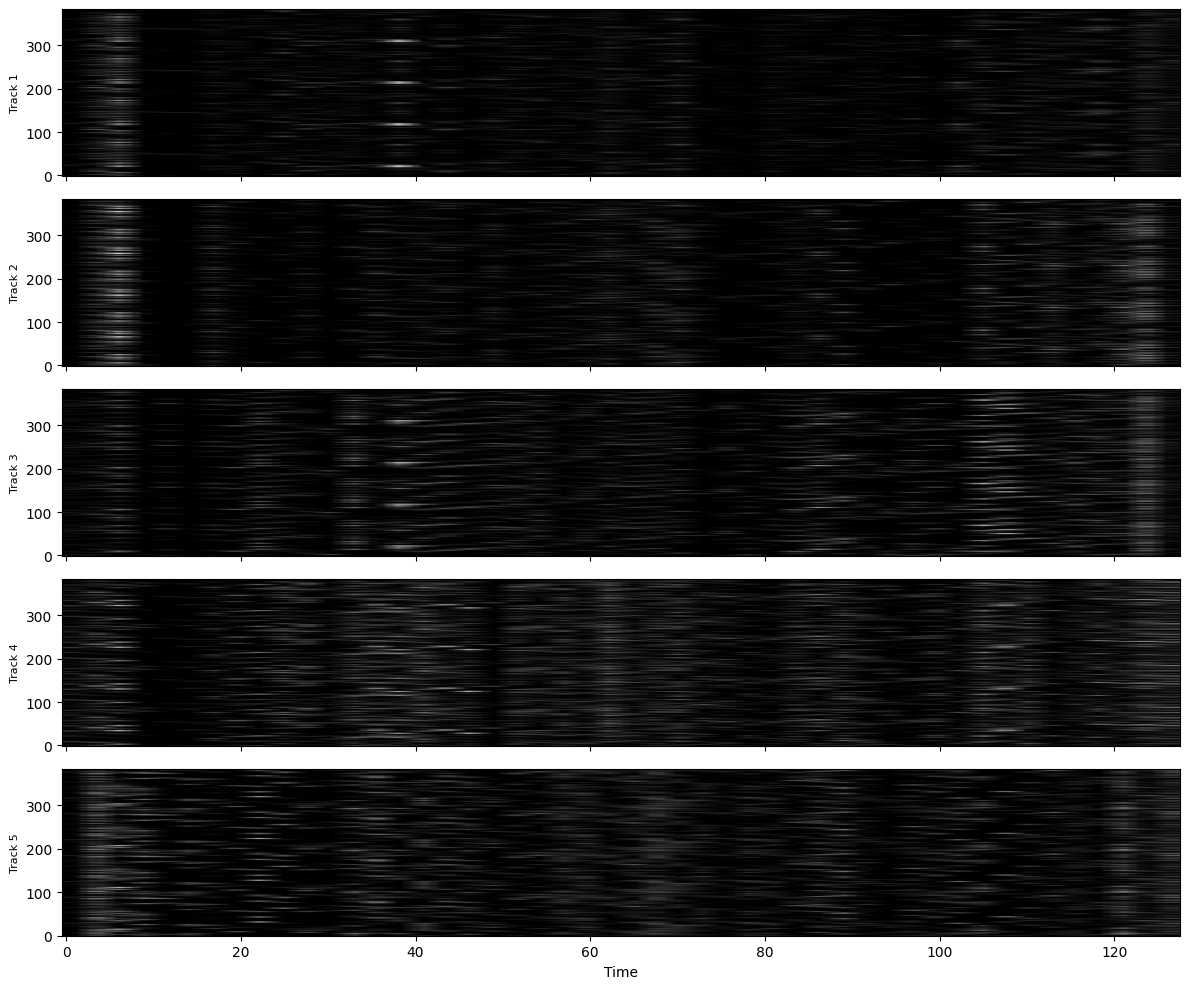

In [18]:
z = torch.randn(batch_size, num_tracks, time_steps, z_t_dim, device=device)
z_t = torch.randn(batch_size, time_steps, z_t_dim, device=device)
z_i_list = [torch.randn(batch_size, z_i_dim, device=device) for _ in range(num_tracks)
]
z_it_list = [
    [torch.randn(batch_size, z_it_dim, device=device) for _ in range(time_steps)]
    for _ in range(num_tracks)
]
fake = generator(z, z_t, z_i_list, z_it_list)
sample = fake[0].detach().cpu().numpy()   # shape: (num_tracks, time, pitch)

num_tracks = sample.shape[0]
fig, axes = plt.subplots(num_tracks, 1, figsize=(12, 2*num_tracks), sharex=True)

for i in range(num_tracks):
    axes[i].imshow(sample[i].T, aspect="auto", origin="lower", cmap="gray")
    axes[i].set_ylabel(f"Track {i+1}", fontsize=8)
    if i == num_tracks - 1:
        axes[i].set_xlabel("Time")

plt.tight_layout()
plt.show()

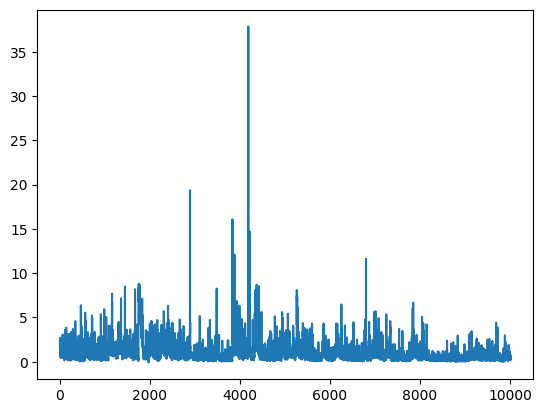

In [19]:
plt.plot(Dlosses)
plt.show()

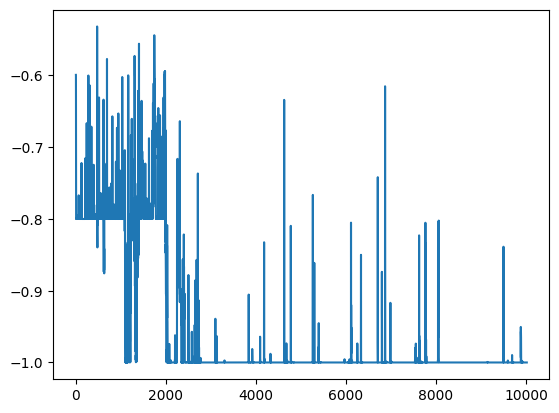

In [20]:
plt.plot(GLosses)
plt.show()